In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import pyro
from pyro.infer.autoguide import AutoLowRankMultivariateNormal
from pyro.infer import Predictive
import pyro.distributions as dist
from pyro.optim import Adam
import random
import pandas as pd
import scipy.io as sio
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import gc

# import user-defined files
from utils.Reservoir import Reservoir
from utils.ESNVariational import ESNVariational
from utils.ESNDataset import ESNDataset
from utils.prediction_curve import prediction_curve
from utils.construct_dataset import construct_dataset
from methods_2 import evaluate_metrics
from recursive_inference import recursive_inference

## Training

Example of training and testing

In [3]:
# Load the MAT file
mat_file = sio.loadmat('100307.REST1.LR.SchaeferS.ptseries.mat')
 
print(mat_file.keys())

dict_keys(['__header__', '__version__', '__globals__', 'tseries'])


In [4]:
data = torch.from_numpy(mat_file['tseries']).float()

In [4]:
## PYRO MODEL
# states is a batch of states of size (batch dimension, neurons per state)
def model_fn(states, scale = 0.1, targets=None):
    N_neurons = states.shape[1]
    # We sample the Readout Weights R
    # .to_event(2) ensures Pyro treats this as a matrix, not independent scalars
    R = pyro.sample("R", dist.Normal(torch.zeros(N_neurons, 119), 1.0).to_event(2))
    
    # Linear projection to find the mean load
    mu = (states @ R)
    
    # Observation noise (how much we expect the real data to fluctuate around mu)
    sigma = pyro.sample("sigma", dist.HalfNormal(scale))
    
    with pyro.plate("data", states.shape[0]):
        return pyro.sample("obs", dist.Normal(mu, sigma).to_event(1), obs=targets)

Compute the metrics to evaluate the results

## Random search

We now want to try to optimize the architecture by tuning the hyperparameters of the system, in particular we vary:
- Spectral radius of $W$
- Number of neurons
- Reservoir's activation function
- Adam's learning rate
- Sampled weights variance

In [5]:
# parameters space
spectral_radius_list = [0.1,0.3,0.5,0.7,0.9,1.1]
neurons_list = [16, 32, 64, 128, 256]
activations_list = [nn.ReLU(), nn.Tanh()] 
learning_rates = [0.0001, 0.001, 0.01]
scales = [0.01, 0.1, 1.0]
INPUT_DIM = data.shape[0]

# ranges for each region (used to normalize the mcrps)

ranges = data.max(dim=1).values - data.min(dim=1).values
      

In [6]:
num_iterations = 100
results = []

for i in range(num_iterations):
    # Clear Pyro's parameter store to prevent memory leaks across trials
    pyro.clear_param_store()
    
    # Sample hyperparameters randomly for this trial
    n = random.choice(neurons_list)
    act_name = random.choice(activations_list)
    lr = random.choice(learning_rates)
    s = random.choice(scales)
    spectral_radius = random.choice(spectral_radius_list)
    
    print(f"\n--- Trial {i+1}/{num_iterations} ---")
    print(f"Parameters: Neurons={n}, Activation={act_name}, LR={lr}, Scale={s}, Spectral radius={spectral_radius}")

    try:
        # Setup Optimizer and Pyro Guide
        optimizer = pyro.optim.Adam({"lr": lr})
        
        RANK = int(np.sqrt(n))  # Rank for the Multivariate Normal
        guide = AutoLowRankMultivariateNormal(model_fn, rank=RANK)

        # Instantiate the Bayesian ESN model
        esn_var = ESNVariational(
            N=n, 
            K=INPUT_DIM, 
            pyro_model=model_fn, 
            pyro_guide=guide, 
            optimizer=optimizer,
            spectral_radius=spectral_radius,
            scale=s
        )
        
        esn_var.reservoir.activation = act_name 

        # Construct dataset and DataLoader for this specific reservoir state
        train_ds, valid_ds = construct_dataset(esn_var.reservoir, data.T, train_split=0.7)
        current_train_loader = torch.utils.data.DataLoader(train_ds, batch_size=16, shuffle=True)

        # Train the model
        esn_var.train(current_train_loader, epochs=100)

        # Disable gradient tracking to save massive amounts of RAM during inference
        with torch.no_grad():
            scaler = {'mean': train_ds.mean, 'std': train_ds.std}
            
            # Get predictions
            y_true_eval, y_samples_eval, *_ = prediction_curve(esn_var, valid_ds, scaler = scaler, plot=False, num_samples = 1000)
            
            # Detach tensors from the computational graph to ensure they don't hold memory
            if isinstance(y_true_eval, torch.Tensor):
                y_true_eval = y_true_eval.detach()
            if isinstance(y_samples_eval, torch.Tensor):
                y_samples_eval = y_samples_eval.detach()
            
            # Calculate metrics
            ecov, cal, mcrps = evaluate_metrics(y_samples_eval, y_true_eval)

            ecov = ecov.mean().item()
            cal = cal.mean().item()

            # Convert the vector of mCRPS into a normalized average
            n_mcrps = mcrps / ranges
            avg_mcrps = n_mcrps.mean().item()

        results.append({
            'neurons': n,
            'activation': act_name,
            'lr': lr,
            'spectral_radius': spectral_radius,
            'scale': s,
            'ecov': ecov,
            'cal': cal,
            'avg_mcrps': avg_mcrps
        })

        # Delete heavy objects created in this iteration
        del esn_var
        del guide
        del optimizer
        del train_ds
        del valid_ds
        del current_train_loader
        del y_true_eval
        del y_samples_eval
        del scaler
        
        # Force Python's Garbage Collector to free the unreferenced memory immediately
        gc.collect()
        
    except Exception as e:
        print(f"Error at iteration {i+1}: {e}")
        # Ensure cleanup even if an error occurs to prevent cascading Out-Of-Memory errors
        gc.collect()


--- Trial 1/100 ---
Parameters: Neurons=64, Activation=ReLU(), LR=0.0001, Scale=0.1, Spectral radius=0.1


Training Pyro ESN:   0%|          | 0/100 [00:00<?, ?it/s]

Training Pyro ESN:   1%|          | 1/100 [00:06<11:13,  6.81s/it, Loss=1570360.2666]

Epoch 0 | Total ELBO Loss: 1570360.2666


Training Pyro ESN: 100%|██████████| 100/100 [00:39<00:00,  2.52it/s, Loss=213238.1853]


...

Training Pyro ESN: 100%|██████████| 100/100 [01:06<00:00,  1.51it/s, Loss=4524.5179]



--- Trial 100/100 ---
Parameters: Neurons=32, Activation=Tanh(), LR=0.0001, Scale=1.0, Spectral radius=0.1


Training Pyro ESN:   1%|          | 1/100 [00:00<00:28,  3.43it/s, Loss=1124.7008]

Epoch 0 | Total ELBO Loss: 1124.7008


Training Pyro ESN: 100%|██████████| 100/100 [00:27<00:00,  3.61it/s, Loss=686.3033]


In [7]:
df_results = pd.DataFrame(results)
df_results['ecov_dist'] = (df_results['ecov'] - 0.95).abs()

# Order the results
best_models = df_results.sort_values(by=['cal', 'ecov_dist', 'avg_mcrps'])

print(best_models.head(5))


    neurons activation      lr  spectral_radius  scale      ecov       cal  \
99       32     Tanh()  0.0001              0.1    1.0  0.940007  0.000953   
83      256     Tanh()  0.0010              0.5    0.1  0.936573  0.001070   
18      256     Tanh()  0.0100              0.9    0.1  0.994666  0.001530   
58       64     Tanh()  0.0010              0.1    1.0  1.000000  0.001606   
92       16     Tanh()  0.0100              1.1    1.0  1.000000  0.001606   

    avg_mcrps  ecov_dist  
99   0.101485   0.009993  
83   0.116634   0.013427  
18   0.088146   0.044666  
58   0.240780   0.050000  
92   0.114866   0.050000  


In [8]:
best_models.iloc[0,:]

neurons                  32
activation           Tanh()
lr                   0.0001
spectral_radius         0.1
scale                   1.0
ecov               0.940007
cal                0.000953
avg_mcrps          0.101485
ecov_dist          0.009993
Name: 99, dtype: object

## Best model

In [9]:
best_params = best_models.iloc[0,:]
best_params

neurons                  32
activation           Tanh()
lr                   0.0001
spectral_radius         0.1
scale                   1.0
ecov               0.940007
cal                0.000953
avg_mcrps          0.101485
ecov_dist          0.009993
Name: 99, dtype: object

In [ ]:
# save best parameters
df_save = best_params.reset_index()
df_save.columns = ['parameter', 'value']

df_save.to_csv("best_parameters.csv", index=False)

## Load best model

In [5]:
# decomment if reading from file:
best_params = pd.read_csv("best_parameters.csv")

In [6]:
pyro.clear_param_store()

In [7]:
best_params = best_params.set_index('parameter')['value']

In [8]:
# PARAMETERS

N_NEURONS = int(best_params['neurons'])
INPUT_DIM = data.shape[0] # equals to output dim

LR = float(best_params['lr'])
act_name = nn.Tanh() if best_params['activation'] == 'Tanh()' else nn.ReLU()
EPOCHS = 100

# Setup Optimizer
optimizer = pyro.optim.Adam({"lr": LR})

In [9]:
## PYRO MODEL
# states is a batch of states of size (batch dimension, neurons per state)
def model_fn(states, scale = 0.1, targets=None):
    N_neurons = states.shape[1]
    # We sample the Readout Weights R
    # .to_event(2) ensures Pyro treats this as a matrix, not independent scalars
    R = pyro.sample("R", dist.Normal(torch.zeros(N_neurons, 119), 1.0).to_event(2))
    
    # Linear projection to find the mean load
    mu = (states @ R)
    
    # Observation noise (how much we expect the real data to fluctuate around mu)
    sigma = pyro.sample("sigma", dist.HalfNormal(scale))
    
    with pyro.plate("data", states.shape[0]):
        return pyro.sample("obs", dist.Normal(mu, sigma).to_event(1), obs=targets)

In [10]:
# PYRO GUIDE

RANK = int(np.sqrt(N_NEURONS))  # Rank for the Multivariate Normal
guide = AutoLowRankMultivariateNormal(model_fn, rank=RANK)

In [11]:
# Initialize the ESNVariational
esn_var = ESNVariational(
    N_NEURONS, 
    INPUT_DIM, 
    model_fn, 
    guide, 
    optimizer, 
    spectral_radius = float(best_params['spectral_radius']),
    scale = float(best_params['scale'])
)


In [12]:
esn_var.reservoir.activation = act_name

In [13]:
train_ds, _ = construct_dataset(esn_var.reservoir, data.T, train_split=1.0, burnin=100)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)

In [14]:
# retrain on the full first dataset
history = esn_var.train(train_loader, EPOCHS)

Training Pyro ESN:   1%|          | 1/100 [00:12<20:06, 12.19s/it, Loss=1342.0390]

Epoch 0 | Total ELBO Loss: 1342.0390


Training Pyro ESN: 100%|██████████| 100/100 [01:02<00:00,  1.60it/s, Loss=665.2518]


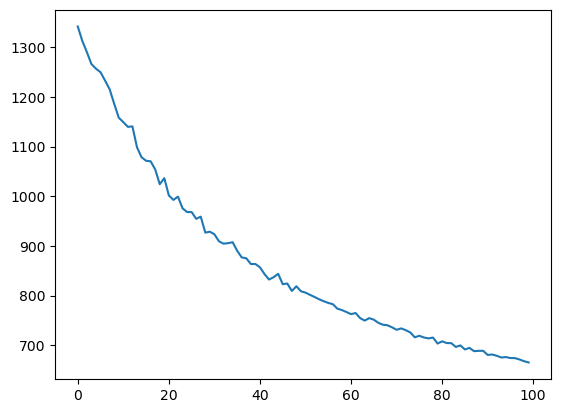

In [15]:
plt.plot(history)

In [16]:
# fetch test dataset
data_test = torch.from_numpy(sio.loadmat('100307.REST2.LR.SchaeferS.ptseries.mat')['tseries']).float()

In [17]:
# Generate Torch datasets
test_ds, _ = construct_dataset(esn_var.reservoir, data.T, train_split=1.0, burnin=100)

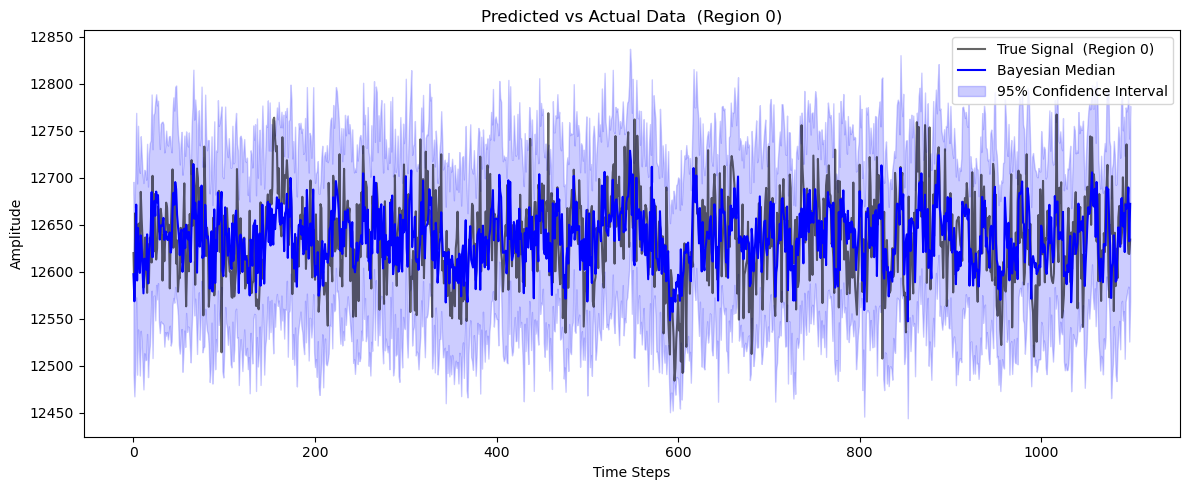

In [18]:
# predict
scaler = {"mean": test_ds.mean, "std": test_ds.std}
y_true, y_samples, y_mean, upper, lower = prediction_curve(esn_var, test_ds, scaler = scaler, num_samples = 1000)

In [19]:
# metrics
ecov, cal, mcrps = evaluate_metrics(y_samples, y_true)

# ranges for each region (used to normalize the mcrps)
ranges = y_true.max(dim=0).values - y_true.min(dim=0).values


# convert the vector of mrcps in a normalized avergae
n_mcrps = mcrps / ranges

avg_mcrps = n_mcrps.mean().item()

In [20]:
std_ecov = np.std(ecov.detach().numpy())/np.sqrt(len(ecov))
std_cal = np.std(cal.detach().numpy())/np.sqrt(len(cal))
std_mcrps = np.std(n_mcrps.detach().numpy())/np.sqrt(len(n_mcrps))


# Rounding to 4 decimal places for precision, or change .4f to .3f for 3 places
print(f"Empirical Coverage: {ecov.mean().item():.3f} ± {std_ecov:.3f}")
print(f"Calibration Error:  {cal.mean().item():.5f} ± {std_cal:.5f}")
print(f"mCRPS (Normalized): {avg_mcrps:.4f} ± {std_mcrps:.4f}")

Empirical Coverage: 0.956 ± 0.002
Calibration Error:  0.00036 ± 0.00003
mCRPS (Normalized): 0.0904 ± 0.0009


## Visualizations

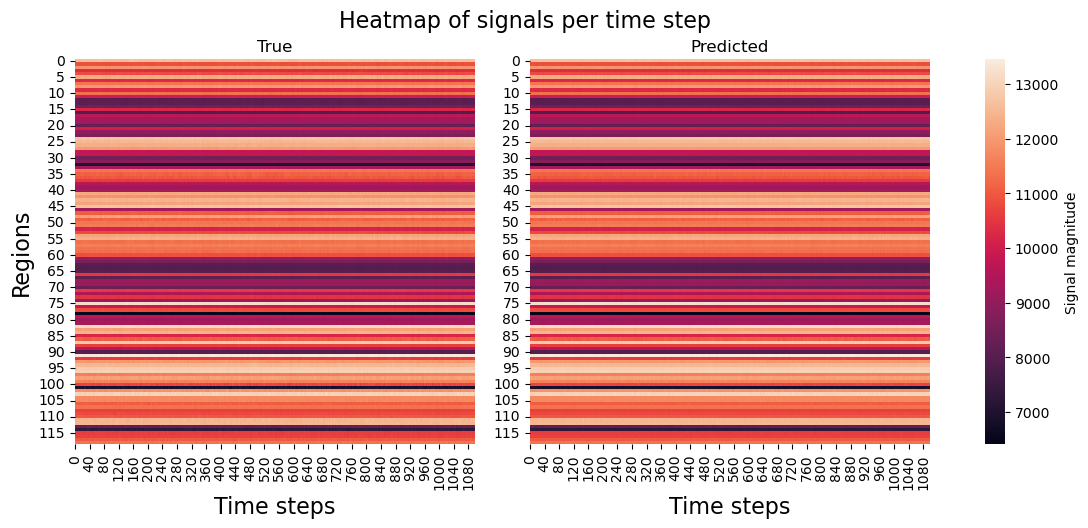

In [21]:
fig, ax = plt.subplots(1,3, figsize = (12,5), gridspec_kw={'width_ratios': [1, 1, 0.05]})
fig.suptitle('Heatmap of signals per time step', fontsize = 16)


ax[0].set_title('True')
# Set the labels
sns.heatmap(y_true.T, cbar = False, ax=ax[0])
ax[0].set_xlabel("Time steps", fontsize=16)
ax[0].set_ylabel("Regions", fontsize=16)



sns.heatmap(y_mean.T,  cbar_kws={'label': 'Signal magnitude'}, ax = ax[1], cbar_ax= ax[2])

# Set the labels
ax[1].set_title('Predicted')
ax[1].set_xlabel("Time steps", fontsize=16)
#ax[1].set_ylabel("Regions", fontsize=16)

plt.show()


## heatmap mCRPS

In [22]:
num_samples = y_samples.shape[0]
    
# quantiles grid
tau_grid = torch.linspace(0.0, 1.0, 101)


# shape: [101, Time, Regions]
q = torch.quantile(y_samples, tau_grid, dim=0)


# y_true_extended has shape [1, Time, Regions] for broadcasting
y_true_extended = y_true.unsqueeze(0)
errors = y_true_extended - q  # [101, Time, Regions]

# Pinball Loss
# tau_grid_extended has shape [101, 1, 1] --> done for broadcasting
tau_grid_extended = tau_grid.view(-1, 1, 1)
loss = torch.max(tau_grid_extended * errors, (tau_grid_extended - 1) * errors)

In [23]:
data_heatmap = loss.mean(dim=0).T
ranges_extended = ranges.repeat(data_heatmap.shape[1],1).T
data_heatmap = (data_heatmap/ranges_extended) * 100

Text(170.72222222222223, 0.5, 'Regions')

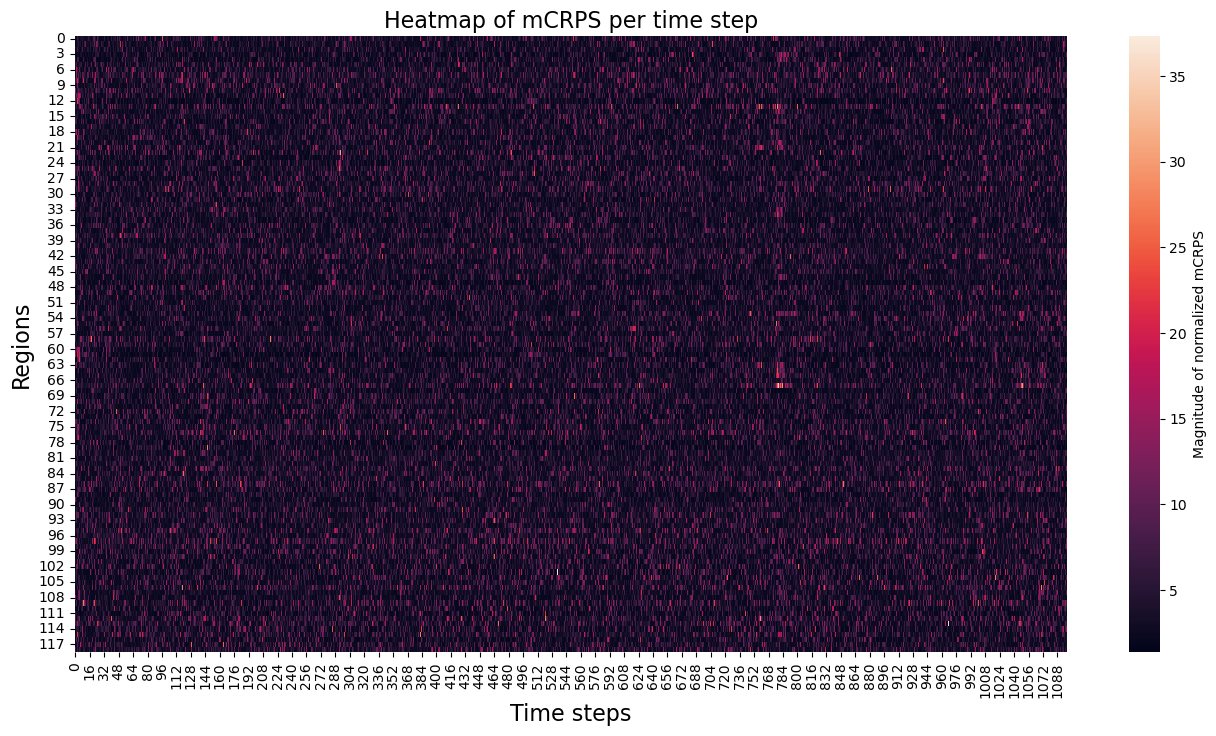

In [24]:
plt.figure(figsize=(16,8))
plt.title('Heatmap of mCRPS per time step', fontsize = 16)

ax = sns.heatmap(data_heatmap, cbar_kws={'label': 'Magnitude of normalized mCRPS'})
ax.set_xlabel("Time steps", fontsize=16)
ax.set_ylabel("Regions", fontsize=16)

## Recursive forecasting

In [46]:
# 1. Run the inference
y_rec_rescaled, y_samples, y_upper, y_lower = recursive_inference(esn_var, test_ds, steps = 50)


Step 0/50...


ValueError: not enough values to unpack (expected 4, got 2)

In [ ]:
# 2. Un-scale BOTH for a fair comparison
y_true_abs = test_ds.predictions
y_pred_abs = (y_rec_rescaled * test_ds.std) + test_ds.mean
y_samples_scaled = (y_samples * test_ds.std) + test_ds.mean
y_upper_scaled = (y_upper * test_ds.std) + test_ds.mean
y_lower_scaled = (y_lower * test_ds.std) + test_ds.mean

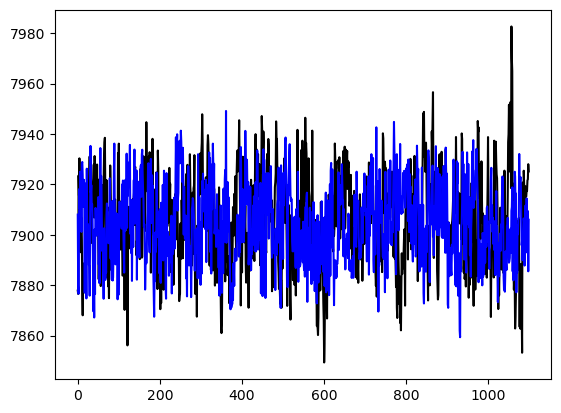

In [ ]:
region_idx = 0

# 3. Plot Region 13
plt.plot(y_true_abs[:, 16].cpu(), color='black', label='Ground Truth')
plt.plot(y_pred_abs[:, 16].cpu(), color='blue', label='Stable Recursive Prediction')

plt.fill_between(
    range(len(y_pred_abs)), 
    y_lower_scaled[:, region_idx].cpu(), 
    y_upper_scaled[:, region_idx].cpu(), 
    color='blue', 
    alpha=0.2,   # Trasparenza per rendere visibile il GT sotto la fascia
    label='95% Confidence Interval'
)

# Formattazione del grafico
plt.title(f"Recursive Prediction vs Ground Truth - Region {region_idx}", fontsize=14)
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Normalized BOLD Signal", fontsize=12)
plt.legend(loc='upper right')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# --- 1. PREPARE THE ABSOLUTE GROUND TRUTH ---
# We must compare our integrated wave against the absolute positions, not the deltas.
y_true_abs_scaled = test_ds.predictions.to(y_rec_rescaled.device)

# --- 2. EVALUATE METRICS ---
# ecov: Expected Coverage (Are the samples within the CI?)
# cal: Calibration (Is the uncertainty estimated correctly?)
# mcrps: Mean Continuously Ranked Probability Score
ecov, cal, mcrps = evaluate_metrics(y_samples_scaled, y_true_abs_scaled)

# --- 3. NORMALIZE mCRPS BY REGION RANGE ---
# We calculate the range (max - min) for each of the 119 brain regions.
# This accounts for the fact that some regions have higher amplitude than others.
ranges = y_true_abs_scaled.max(dim=0).values - y_true_abs_scaled.min(dim=0).values

# Avoid division by zero for quiet regions
ranges_safe = ranges + 1e-8

# n_mcrps: Normalized mCRPS per region
n_mcrps = mcrps / ranges_safe

# --- 4. AVERAGE RESULTS ---
avg_mcrps = n_mcrps.mean().item()

std_ecov = np.std(ecov.detach().numpy())/np.sqrt(len(ecov))
std_cal = np.std(cal.detach().numpy())/np.sqrt(len(cal))
std_mcrps = np.std(n_mcrps.detach().numpy())/np.sqrt(len(n_mcrps))


# Rounding to 4 decimal places for precision, or change .4f to .3f for 3 places
print(f"Empirical Coverage: {ecov.mean().item():.3f} ± {std_ecov:.3f}")
print(f"Calibration Error:  {cal.mean().item():.5f} ± {std_cal:.5f}")
print(f"mCRPS (Normalized): {avg_mcrps:.4f} ± {std_mcrps:.4f}")

Empirical Coverage: 0.902 ± 0.003
Calibration Error:  0.00187 ± 0.00018
mCRPS (Normalized): 0.1109 ± 0.0014


 METRICHE SPETTRALI GLOBALI (su 119 regioni)
Global Spectral MAE:         0.0873  (Ideale: 0.0)
Global Spectral KS-Distance: 0.1895  (Ideale: 0.0)


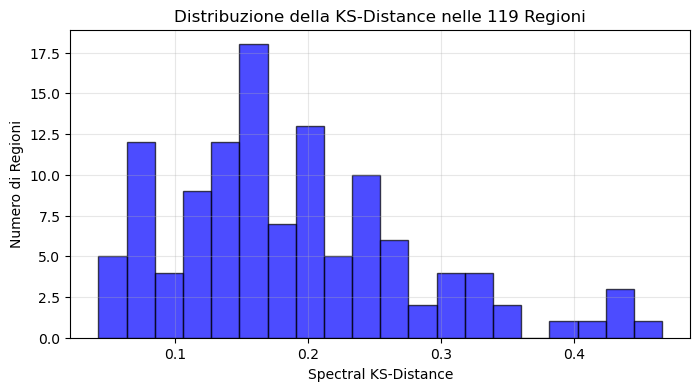

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ==========================================
# 1. PREPARAZIONE DATI (Tutte le 119 regioni)
# ==========================================
# Assicurati che questi abbiano forma [steps, 119]
y_true_all = y_true_abs_scaled.cpu().numpy()
y_pred_all = y_rec_rescaled.cpu().numpy()

n_regions = y_true_all.shape[1]
tr = 1.0  # Ripetizione (TR) del fMRI, lascia 1.0 se non lo sai
fs = 1.0 / tr
nperseg = min(256, y_true_all.shape[0])

# Liste per salvare gli errori di ciascuna regione
spectral_mae_list = []
spectral_ks_list = []

# ==========================================
# 2. CALCOLO REGIONE PER REGIONE
# ==========================================
for i in range(n_regions):
    y_t = y_true_all[:, i]
    y_p = y_pred_all[:, i]
    
    # Welch PSD
    f_true, Pxx_true = welch(y_t, fs=fs, nperseg=nperseg)
    f_pred, Pxx_pred = welch(y_p, fs=fs, nperseg=nperseg)
    
    # Normalizzazione ed energia cumulativa
    cum_true = np.cumsum(Pxx_true / np.sum(Pxx_true))
    cum_pred = np.cumsum(Pxx_pred / np.sum(Pxx_pred))
    
    # Calcolo metriche per questa singola regione
    spectral_mae_list.append(np.mean(np.abs(cum_true - cum_pred)))
    spectral_ks_list.append(np.max(np.abs(cum_true - cum_pred)))

# ==========================================
# 3. AGGREGAZIONE GLOBALE
# ==========================================
global_mae = np.mean(spectral_mae_list)
global_ks = np.mean(spectral_ks_list)

print("======================================================")
print(f" METRICHE SPETTRALI GLOBALI (su {n_regions} regioni)")
print("======================================================")
print(f"Global Spectral MAE:         {global_mae:.4f}  (Ideale: 0.0)")
print(f"Global Spectral KS-Distance: {global_ks:.4f}  (Ideale: 0.0)")

# Plot della distribuzione degli errori (Opzionale)
plt.figure(figsize=(8, 4))
plt.hist(spectral_ks_list, bins=20, color='blue', alpha=0.7, edgecolor='black')
plt.title('Distribuzione della KS-Distance nelle 119 Regioni')
plt.xlabel('Spectral KS-Distance')
plt.ylabel('Numero di Regioni')
plt.grid(alpha=0.3)
plt.show()